# CNN - Оценка на модела (Evaluation)
Този ноутбук зарежда обучения модел и го оценява върху тестовия набор от данни.

In [1]:
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.models.CNN_model import AudioCNN
from src.data_processing.urbansound_dataset import UrbanSoundDataset

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Използвано устройство: {DEVICE}")

TEST_CSV = "../data/test_split.csv"
AUDIO_DIR = "../data/processed_audio"
MODEL_WEIGHTS = "../models/best_cnn.pth"
BATCH_SIZE = 32

Използвано устройство: cpu


In [3]:
print("Зареждане на тестовите данни...")
test_dataset = UrbanSoundDataset(csv_file=TEST_CSV, audio_dir=AUDIO_DIR)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Брой тестови записи: {len(test_dataset)}")

Зареждане на тестовите данни...
Брой тестови записи: 1653


In [4]:
print("Инициализация на модела...")
model = AudioCNN(n_classes=10).to(DEVICE)

print("Зареждане на запазените тегла...")
if os.path.exists(MODEL_WEIGHTS):
    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=DEVICE))
    model.eval()
    print("Моделът е зареден успешно!")
else:
    print(f"ГРЕШКА: Файлът с теглата не е намерен на път {MODEL_WEIGHTS}")

Инициализация на модела...
Зареждане на запазените тегла...
Моделът е зареден успешно!


In [5]:
all_preds = []
all_labels = []

print("Стартиране на инференцията...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Оценката приключи!")

Стартиране на инференцията...


Testing:   0%|          | 0/52 [00:00<?, ?it/s]

Оценката приключи!


In [6]:
class_names = [
    "air_conditioner", "car_horn", "children_playing", "dog_bark",
    "drilling", "engine_idling", "gun_shot", "jackhammer",
    "siren", "street_music"
]

print("--- Доклад от класификацията (Classification Report) ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

--- Доклад от класификацията (Classification Report) ---
                  precision    recall  f1-score   support

 air_conditioner       0.69      0.54      0.61       200
        car_horn       0.87      0.80      0.83        65
children_playing       0.70      0.78      0.74       200
        dog_bark       0.68      0.71      0.70       200
        drilling       0.82      0.79      0.81       200
   engine_idling       0.66      0.61      0.63       182
        gun_shot       0.89      0.92      0.91        63
      jackhammer       0.64      0.80      0.71       178
           siren       0.84      0.72      0.78       165
    street_music       0.79      0.86      0.83       200

        accuracy                           0.74      1653
       macro avg       0.76      0.75      0.75      1653
    weighted avg       0.74      0.74      0.74      1653



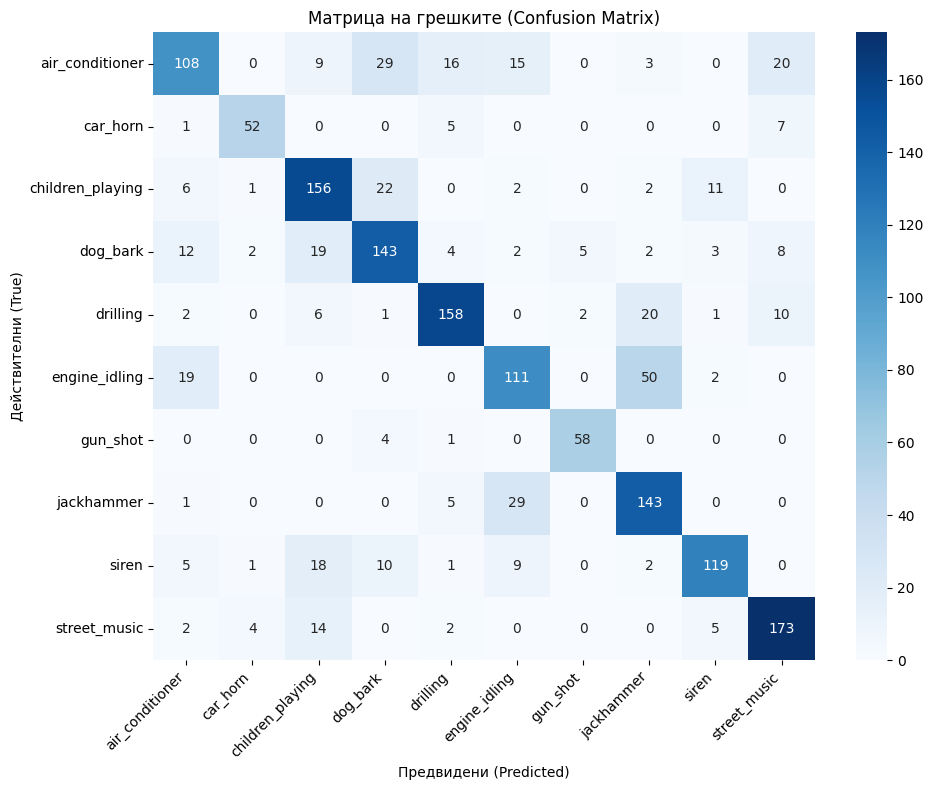

In [7]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предвидени (Predicted)')
plt.ylabel('Действителни (True)')
plt.title('Матрица на грешките (Confusion Matrix)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()